In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df = pd.read_csv("spam.csv",encoding="latin-1")


In [45]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [46]:
df.sample(3)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4307,ham,Ha ha - had popped down to the loo when you he...,NaN,NaN,NaN
1280,ham,Oh ho. Is this the first time u use these type...,NaN,NaN,NaN
2069,spam,"Eerie Nokia tones 4u, rply TONE TITLE to 8007 ...",NaN,NaN,NaN


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [48]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [49]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],inplace=True)

In [50]:
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [51]:
df["v1"].value_counts()

,count
v1,
ham,4825
spam,747


In [52]:
df[df["v1"]=="ham"]["v2"][6]


'Even my brother is not like to speak with me. They treat me like aids patent.'

In [53]:
df.rename(columns={"v1":"Target","v2":"Text"},inplace=True)

In [54]:
df

,Target,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


<Axes: xlabel='Target'>

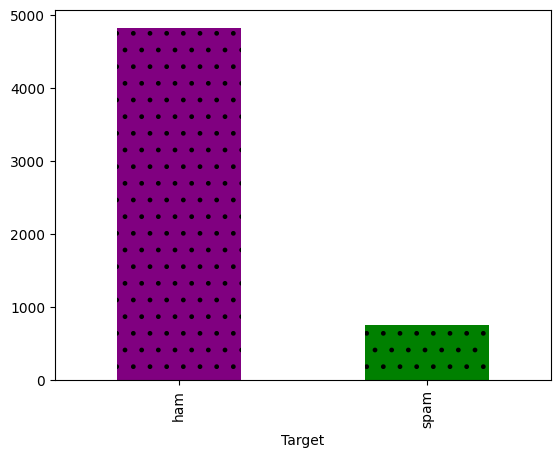

In [55]:
df["Target"].value_counts().plot( kind="bar", color=["purple","green"],hatch=".")

In [56]:
df.duplicated().sum()
np.int64(403)

np.int64(403)

In [57]:
df.drop_duplicates(keep="first",inplace=True)

In [58]:
df.duplicated().sum()

np.int64(0)

In [59]:
df

,Target,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [60]:
df.shape

(5169, 2)

In [61]:
! pip install nltk

In [62]:
import nltk
nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [63]:
df["num_chars"]=df["Text"].apply(len)


In [64]:
df.sample(3)

,Target,Text,num_chars
695,ham,Good. Good job. I like entrepreneurs,36
2877,spam,Hey Boys. Want hot XXX pics sent direct 2 ur p...,140
2698,spam,FROM 88066 LOST å£12 HELP,25


In [65]:
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [66]:
df["num_words"] =df["Text"].apply(len)

In [67]:
df.sample(3)

,Target,Text,num_chars,num_words
2322,ham,Should I be stalking u?,23,23
2281,ham,"I hav almost reached. Call, i m unable to conn...",52,52
1150,ham,(That said can you text him one more time?),43,43


In [68]:
df["num_words"] =df["Text"].apply(lambda x: len(nltk.word_tokenize(x)))

In [69]:
df

,Target,Text,num_chars,num_words
0,ham,"Go until jurong point, crazy.. Available only ...",111,24
1,ham,Ok lar... Joking wif u oni...,29,8
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,ham,U dun say so early hor... U c already then say...,49,13
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15
...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35
5568,ham,Will Ì_ b going to esplanade fr home?,37,9
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15
5570,ham,The guy did some bitching but I acted like i'd...,125,27


In [72]:
df["num_sent"] =df["Target"].apply(lambda x: len(nltk.word_tokenize(x)))

In [73]:
df

,Target,Text,num_chars,num_words,num_sent
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,1
1,ham,Ok lar... Joking wif u oni...,29,8,1
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,1
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35,1
5568,ham,Will Ì_ b going to esplanade fr home?,37,9,1
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15,1
5570,ham,The guy did some bitching but I acted like i'd...,125,27,1


In [74]:
df["num_sent"] =df["Target"].apply(lambda x: len(nltk.sent_tokenize(x)))

In [75]:
df

,Target,Text,num_chars,num_words,num_sent
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,1
1,ham,Ok lar... Joking wif u oni...,29,8,1
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,1
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35,1
5568,ham,Will Ì_ b going to esplanade fr home?,37,9,1
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15,1
5570,ham,The guy did some bitching but I acted like i'd...,125,27,1


In [76]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["Target2"] = encoder.fit_transform(df["Target"])


In [77]:
df

,Target,Text,num_chars,num_words,num_sent,Target2
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,1,0
1,ham,Ok lar... Joking wif u oni...,29,8,1,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,1,1
3,ham,U dun say so early hor... U c already then say...,49,13,1,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1,0
...,...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35,1,1
5568,ham,Will Ì_ b going to esplanade fr home?,37,9,1,0
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15,1,0
5570,ham,The guy did some bitching but I acted like i'd...,125,27,1,0


In [78]:
df = df[['Target2','Target', 'Text', 'num_chars', 'num_words', 'num_sent' ]]
df

,Target2,Target,Text,num_chars,num_words,num_sent
0,0,ham,"Go until jurong point, crazy.. Available only ...",111,24,1
1,0,ham,Ok lar... Joking wif u oni...,29,8,1
2,1,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,1
3,0,ham,U dun say so early hor... U c already then say...,49,13,1
4,0,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...,...
5567,1,spam,This is the 2nd time we have tried 2 contact u...,161,35,1
5568,0,ham,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,ham,"Pity, * was in mood for that. So...any other s...",57,15,1
5570,0,ham,The guy did some bitching but I acted like i'd...,125,27,1


In [79]:
nltk.download("stopword")

[nltk_data] Error loading stopword: Package 'stopword' not found in
[nltk_data]     index


False

In [87]:
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
ps = nltk.PorterStemmer

In [88]:
def transform_text(text):
  text = text.lower()
  text = nltk.word_tokenize(text)
  y = []
  for i in text:
    if i.isalnum():
      y.append(i)
  text = y[:]
  y.clear()
  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)
  t=y[:]
  y.clear()
  for i in t:
    y.append(ps.stem(i))
  return " ".join(y)


In [97]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [98]:
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
ps = nltk.PorterStemmer()

In [99]:
df["transformed_text"] = df["Text"].apply(transform_text)

/tmp/ipykernel_3216/3335711490.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["transformed_text"] = df["Text"].apply(transform_text)


In [102]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=250,min_font_size=10,background_color="white")

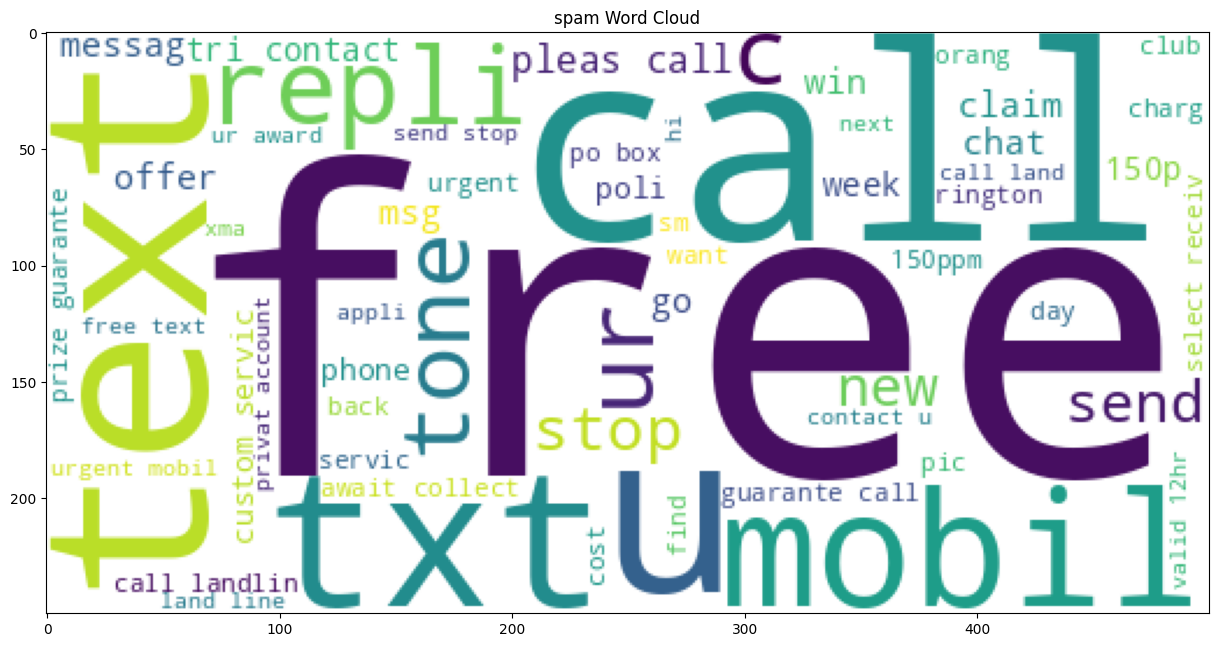

In [104]:
spam_word_cloud = wc.generate(df[df["Target2"]==1]["transformed_text"].str.cat(sep=" "))
plt.figure(figsize=(15,16))
plt.title("spam Word Cloud")
plt.imshow(spam_word_cloud)

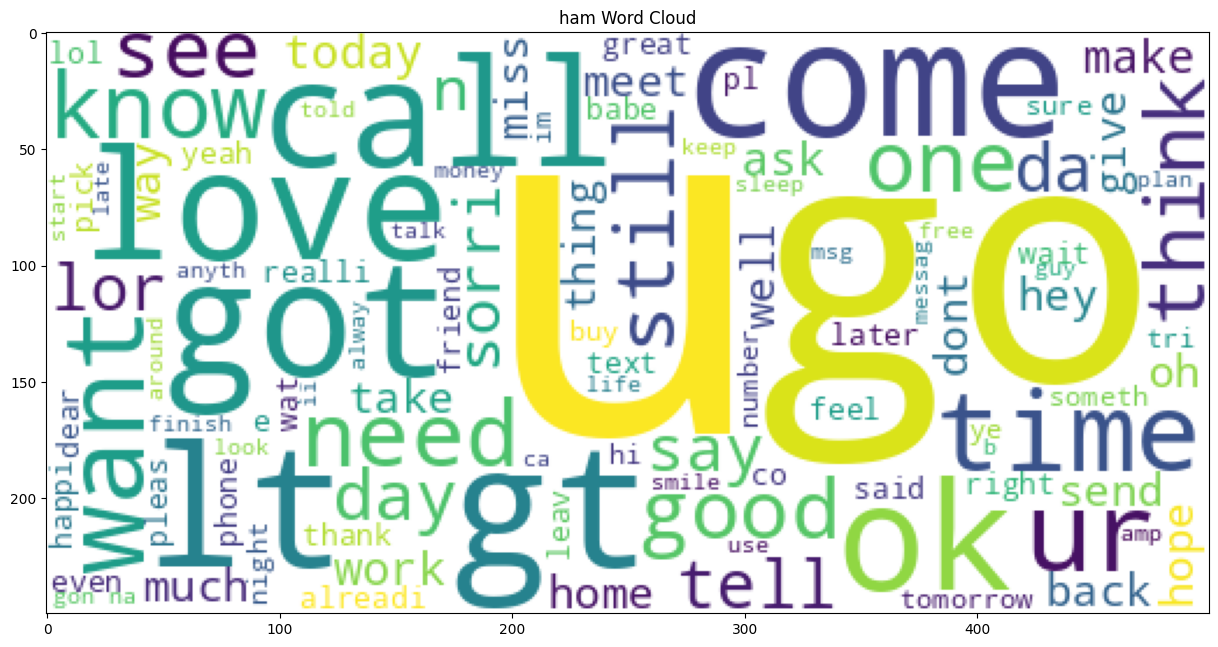

In [109]:
ham_word_cloud = wc.generate(df[df["Target2"]==0]["transformed_text"].str.cat(sep=" "))
plt.figure(figsize=(15,16))
plt.title("ham Word Cloud")
plt.imshow(ham_word_cloud)

# Model Building

In [114]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer,TfidfTransformer
cv = CountVectorizer()
tfidf = TfidfTransformer()

In [115]:
x_counts = cv.fit_transform(df["transformed_text"])
x = tfidf.fit_transform(x_counts).toarray()

In [116]:
y = df["Target2"].values

In [118]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score

In [120]:
mnb = MultinomialNB()
mnb.fit(x_train,y_train)
y_pred = mnb.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy : ",round(accuracy,2))

Accuracy :  0.96


In [123]:
def predict_spam_probability(message):

    # Preprocess
    transformed = transform_text(message)

    # Vectorize
    vector_input = cv.transform([transformed])

    # TF-IDF
    tfidf_input = tfidf.transform(vector_input)

    # Get probabilities
    prob = mnb.predict_proba(tfidf_input)[0]

    return {
        "Ham Probability": round(prob[0], 2),
        "Spam Probability": round(prob[1], 2)
    }

In [124]:
predict_spam_probability("follow this this link to win a cash prize of 20000")


{'Ham Probability': np.float64(0.21), 'Spam Probability': np.float64(0.79)}

In [125]:
predict_spam_probability("I am not felling well, due to heavy rain in delhi")

{'Ham Probability': np.float64(0.95), 'Spam Probability': np.float64(0.05)}